# RAG + Router 기반 LangGraph Agent

## 전체 흐름
```
사용자 질문
    │
[router] ── 의도 분류 (LLM)
    │
┌───┼──────────────┬──────────────┐
│   │              │              │
[rag] [lot_status] [eqp_status] [general]
│   │              │              │
└───┴──────────────┘              │
    │                             │
  [llm] ── 최종 답변 ◄────────────┘
    │
   END
```

| 라우팅 유형 | 설명 |
|---|---|
| `rag` | 내부 지식 베이스 검색 (LangGraph, RAG, FAISS 등) |
| `lot_status` | LOT-xxx 기준 실시간 lot 상태 조회 |
| `eqp_status` | EQP-xxx 기준 장비 호기 상태 조회 |
| `general` | 일반 대화 |

## 1. 패키지 설치

In [ ]:
%pip install -q langgraph langchain langchain-openai langchain-community faiss-cpu

## 2. Import 및 API 키 설정

In [ ]:
import os
import json
from typing import Annotated

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_community.vectorstores import FAISS
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict

# API 키 설정 (환경변수에 없으면 직접 입력)
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = "your-api-key-here"  # 여기에 입력

print("✅ Import 완료")

## 3. RAG 벡터 DB 구성

In [2]:
SAMPLE_DOCS = [
    "LangGraph는 LLM 기반 애플리케이션을 상태 머신(State Machine)으로 구성하는 프레임워크다. "
    "노드(Node)와 엣지(Edge)로 워크플로우를 정의하며, 순환(cycle) 구조도 지원한다.",

    "RAG(Retrieval-Augmented Generation)는 LLM이 외부 지식을 검색해 답변을 생성하는 기법이다. "
    "벡터 DB에서 관련 문서를 검색한 뒤 LLM의 컨텍스트에 포함시켜 정확도를 높인다.",

    "FAISS는 Facebook AI Research에서 만든 고속 벡터 유사도 검색 라이브러리다. "
    "수백만 개의 벡터를 밀리초 단위로 검색할 수 있어 RAG 시스템에 자주 사용된다.",

    "LangChain은 LLM 애플리케이션 개발을 위한 파이썬/자바스크립트 프레임워크다. "
    "체인, 에이전트, 메모리 등의 추상화를 제공하며 LangGraph와 함께 사용된다.",

    "OpenAI의 text-embedding-ada-002 모델은 텍스트를 1536차원 벡터로 변환한다. "
    "의미적으로 유사한 텍스트는 벡터 공간에서 가까운 위치에 배치된다.",
]

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.from_texts(SAMPLE_DOCS, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

print(f"✅ 벡터 DB 준비 완료 — 문서 {len(SAMPLE_DOCS)}개 인덱싱")

✅ 벡터 DB 준비 완료 — 문서 5개 인덱싱


## 4. Mock 실시간 데이터 (LOT / 장비)

> 실제 환경에서는 DB 쿼리나 REST API 호출로 교체

In [4]:
LOT_DB = {
    "LOT-001": {"status": "Processing", "step": "Lithography", "progress": "65%", "eqp": "EQP-A01"},
    "LOT-002": {"status": "Queue",      "step": "Etching",     "progress": "0%",  "eqp": "EQP-B02"},
    "LOT-003": {"status": "Complete",   "step": "Inspection",  "progress": "100%","eqp": "EQP-C01"},
    "LOT-004": {"status": "Hold",       "step": "Deposition",  "progress": "30%", "eqp": "EQP-A02"},
}

EQP_DB = {
    "EQP-A01": {"name": "스캐너 1호기", "status": "Running", "lot": "LOT-001", "util": "92%"},
    "EQP-A02": {"name": "스캐너 2호기", "status": "Hold",    "lot": "LOT-004", "util": "0%"},
    "EQP-B02": {"name": "에처 2호기",   "status": "Idle",    "lot": None,      "util": "0%"},
    "EQP-C01": {"name": "검사기 1호기", "status": "Running", "lot": "LOT-003", "util": "78%"},
}

print("✅ LOT DB:", list(LOT_DB.keys()))
print("✅ EQP DB:", list(EQP_DB.keys()))

✅ LOT DB: ['LOT-001', 'LOT-002', 'LOT-003', 'LOT-004']
✅ EQP DB: ['EQP-A01', 'EQP-A02', 'EQP-B02', 'EQP-C01']


## 5. State 및 LLM 초기화

In [5]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    query_type: str   # "rag" | "lot_status" | "eqp_status" | "general"
    context: str      # 검색/조회 결과

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print("✅ State 정의 완료 / LLM 초기화 완료")

✅ State 정의 완료 / LLM 초기화 완료


## 6. 노드 정의

### 6-1. Router 노드 — 의도 분류

In [6]:
def router_node(state: State) -> dict:
    """사용자 질문을 분석해 처리 유형을 결정한다."""
    user_query = state["messages"][-1].content

    prompt = f"""사용자 질문을 분석해 아래 중 하나의 유형으로만 답하세요. JSON으로만 응답하세요.

유형:
- rag        : AI 기술, LangGraph, RAG, FAISS, LangChain, 임베딩 등 내부 지식 질문
- lot_status : lot_id(LOT-xxx) 기준 반도체 lot 상태 조회
- eqp_status : eqp_id(EQP-xxx) 기준 장비 호기 상태 조회
- general    : 위에 해당 없는 일반 대화

질문: {user_query}

응답 형식: {{"type": "유형", "id": "추출된 ID (없으면 null)"}}"""

    response = llm.invoke([HumanMessage(content=prompt)])
    try:
        parsed = json.loads(response.content)
        query_type = parsed.get("type", "general")
        extracted_id = parsed.get("id")
    except json.JSONDecodeError:
        query_type = "general"
        extracted_id = None

    print(f"  → [Router] 분류: {query_type}" + (f" | ID: {extracted_id}" if extracted_id else ""))
    return {
        "query_type": query_type,
        "context": extracted_id or "",
    }

print("✅ router_node 정의 완료")

✅ router_node 정의 완료


### 6-2. RAG 노드 — 벡터 DB 검색

In [7]:
def rag_node(state: State) -> dict:
    """벡터 DB에서 관련 문서를 검색한다."""
    user_query = state["messages"][-1].content
    docs = retriever.invoke(user_query)
    if not docs:
        context = "관련 문서를 찾지 못했습니다."
    else:
        context = "\n\n".join(f"[문서 {i+1}] {doc.page_content}" for i, doc in enumerate(docs))
    print(f"  → [RAG] {len(docs)}개 문서 검색 완료")
    return {"context": context}

print("✅ rag_node 정의 완료")

✅ rag_node 정의 완료


### 6-3. LOT Status 노드 — 실시간 LOT 상태 조회

In [8]:
def lot_status_node(state: State) -> dict:
    """lot_id 기준으로 lot 상태를 조회한다."""
    lot_id = state["context"].upper()
    if lot_id in LOT_DB:
        info = LOT_DB[lot_id]
        context = (
            f"LOT ID: {lot_id}\n"
            f"상태: {info['status']}\n"
            f"현재 공정: {info['step']}\n"
            f"진행률: {info['progress']}\n"
            f"투입 장비: {info['eqp']}"
        )
    else:
        context = f"'{lot_id}' LOT 정보를 찾을 수 없습니다. (등록된 LOT: {', '.join(LOT_DB.keys())})"
    print(f"  → [LOT] {lot_id} 상태 조회")
    return {"context": context}

print("✅ lot_status_node 정의 완료")

✅ lot_status_node 정의 완료


### 6-4. EQP Status 노드 — 장비 호기 상태 조회

In [9]:
def eqp_status_node(state: State) -> dict:
    """eqp_id 기준으로 장비 호기 상태를 조회한다."""
    eqp_id = state["context"].upper()
    if eqp_id in EQP_DB:
        info = EQP_DB[eqp_id]
        lot_info = f"처리 중인 LOT: {info['lot']}" if info["lot"] else "처리 중인 LOT: 없음"
        context = (
            f"장비 ID: {eqp_id}\n"
            f"장비명: {info['name']}\n"
            f"상태: {info['status']}\n"
            f"{lot_info}\n"
            f"가동률: {info['util']}"
        )
    else:
        context = f"'{eqp_id}' 장비 정보를 찾을 수 없습니다. (등록된 장비: {', '.join(EQP_DB.keys())})"
    print(f"  → [EQP] {eqp_id} 상태 조회")
    return {"context": context}

print("✅ eqp_status_node 정의 완료")

✅ eqp_status_node 정의 완료


### 6-5. LLM 노드 — 최종 답변 생성

In [10]:
def llm_node(state: State) -> dict:
    """context를 바탕으로 최종 답변을 생성한다."""
    user_query = state["messages"][-1].content
    context = state.get("context", "")
    query_type = state.get("query_type", "general")

    if query_type == "general" or not context:
        messages = state["messages"]
    else:
        system_map = {
            "rag":        "아래 검색된 문서를 참고해 질문에 답하세요. 문서에 없는 내용은 모른다고 하세요.",
            "lot_status": "아래 LOT 상태 정보를 바탕으로 사용자에게 현황을 설명하세요.",
            "eqp_status": "아래 장비 상태 정보를 바탕으로 사용자에게 현황을 설명하세요.",
        }
        system_prompt = system_map.get(query_type, "아래 정보를 참고해 답하세요.")
        prompt = f"{system_prompt}\n\n[참고 정보]\n{context}\n\n[질문]\n{user_query}"
        messages = [HumanMessage(content=prompt)]

    response = llm.invoke(messages)
    print(f"  → [LLM] 답변 생성 완료")
    return {"messages": [response]}

print("✅ llm_node 정의 완료")

✅ llm_node 정의 완료


## 7. Graph 구성 및 컴파일

In [11]:
def route_by_type(state: State) -> str:
    return state["query_type"]

graph = (
    StateGraph(State)
    .add_node("router",     router_node)
    .add_node("rag",        rag_node)
    .add_node("lot_status", lot_status_node)
    .add_node("eqp_status", eqp_status_node)
    .add_node("llm",        llm_node)
    .set_entry_point("router")
    .add_conditional_edges("router", route_by_type, {
        "rag":        "rag",
        "lot_status": "lot_status",
        "eqp_status": "eqp_status",
        "general":    "llm",
    })
    .add_edge("rag",        "llm")
    .add_edge("lot_status", "llm")
    .add_edge("eqp_status", "llm")
    .add_edge("llm", END)
    .compile()
)

print("✅ Graph 컴파일 완료")
print("노드:", ["router", "rag", "lot_status", "eqp_status", "llm"])

✅ Graph 컴파일 완료
노드: ['router', 'rag', 'lot_status', 'eqp_status', 'llm']


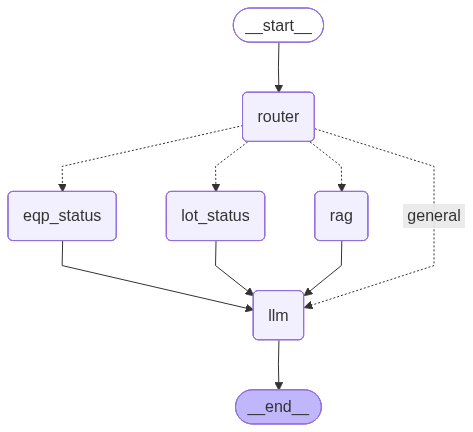

In [12]:
graph

## 8. 실행 함수

In [13]:
def run(query: str):
    print(f"[사용자] {query}")
    print("-" * 50)
    result = graph.invoke({
        "messages":   [HumanMessage(content=query)],
        "query_type": "",
        "context":    "",
    })
    print(f"[AI] {result['messages'][-1].content}")
    print()

## 9. 테스트 실행

### 9-1. RAG — 내부 지식 질문

In [14]:
run("LangGraph가 뭔지 설명해줘")

[사용자] LangGraph가 뭔지 설명해줘
--------------------------------------------------
  → [Router] 분류: rag
  → [RAG] 2개 문서 검색 완료
  → [LLM] 답변 생성 완료
[AI] LangGraph는 LLM 기반 애플리케이션을 상태 머신(State Machine)으로 구성하는 프레임워크입니다. 이 프레임워크는 노드(Node)와 엣지(Edge)를 사용하여 워크플로우를 정의하며, 순환(cycle) 구조도 지원합니다.



### 9-2. LOT Status — LOT 상태 조회

In [15]:
run("LOT-001 상태 알려줘")

[사용자] LOT-001 상태 알려줘
--------------------------------------------------
  → [Router] 분류: lot_status | ID: LOT-001
  → [LOT] LOT-001 상태 조회
  → [LLM] 답변 생성 완료
[AI] LOT-001의 현재 상태는 "Processing"입니다. 현재 공정은 "Lithography"이며, 진행률은 65%입니다. 이 LOT는 EQP-A01 장비에서 작업 중입니다. 전체 공정의 약 65%가 완료된 상태로, 작업이 순조롭게 진행되고 있습니다. 추가적인 정보가 필요하시면 말씀해 주세요!



### 9-3. EQP Status — 장비 호기 상태 조회

In [16]:
run("EQP-A01 장비 호기 상태가 어떻게 돼?")

[사용자] EQP-A01 장비 호기 상태가 어떻게 돼?
--------------------------------------------------
  → [Router] 분류: eqp_status | ID: EQP-A01
  → [EQP] EQP-A01 상태 조회
  → [LLM] 답변 생성 완료
[AI] EQP-A01 장비, 즉 스캐너 1호기의 현재 상태는 "Running"입니다. 이는 장비가 정상적으로 가동 중임을 의미합니다. 현재 처리 중인 LOT는 LOT-001이며, 가동률은 92%로 매우 높은 편입니다. 전반적으로 장비는 안정적으로 운영되고 있으며, 효율적으로 작업을 수행하고 있습니다. 추가적인 문제가 없다면 계속해서 원활한 가동이 예상됩니다.



### 9-4. General — 일반 대화

In [17]:
run("안녕, 오늘 날씨 어때?")

[사용자] 안녕, 오늘 날씨 어때?
--------------------------------------------------
  → [Router] 분류: general
  → [LLM] 답변 생성 완료
[AI] 안녕하세요! 제가 실시간 날씨 정보를 제공할 수는 없지만, 현재 지역의 날씨를 확인하려면 기상청 웹사이트나 날씨 앱을 이용해 보세요. 도움이 필요하시면 언제든지 말씀해 주세요!



### 9-5. 직접 입력해서 테스트

In [ ]:
my_query = "여기에 질문을 입력하세요"
run(my_query)